In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [7]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.52MB/s]

Số ảnh train: 60000,  test: 10000
MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


Epoch 1/5  train_loss=0.1825  train_acc=94.30%  test_loss=0.0628  test_acc=97.93%
Epoch 2/5  train_loss=0.0649  train_acc=98.06%  test_loss=0.0563  test_acc=98.13%
Epoch 3/5  train_loss=0.0494  train_acc=98.50%  test_loss=0.0410  test_acc=98.70%
Epoch 4/5  train_loss=0.0422  train_acc=98.69%  test_loss=0.0496  test_acc=98.52%
Epoch 5/5  train_loss=0.0370  train_acc=98.80%  test_loss=0.0415  test_acc=98.62%


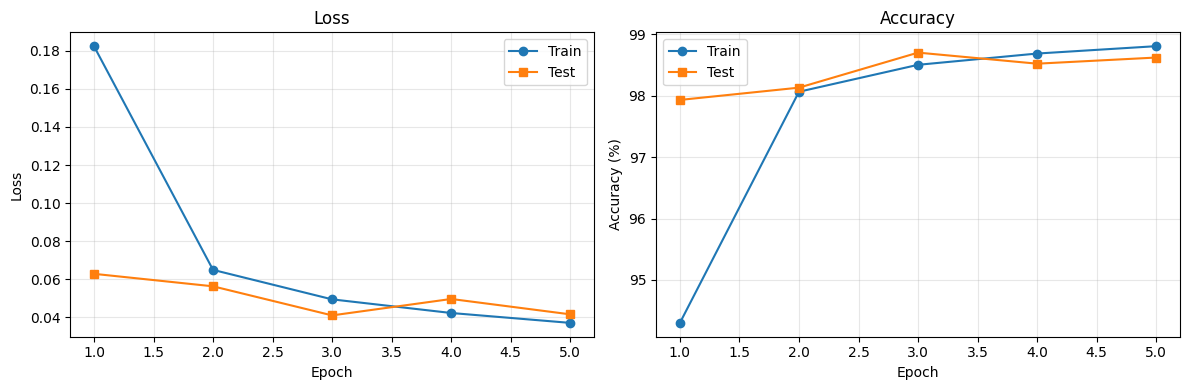

In [3]:
#huấn luyện
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')


epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [4]:
#đánh giá trên test set
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.62%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


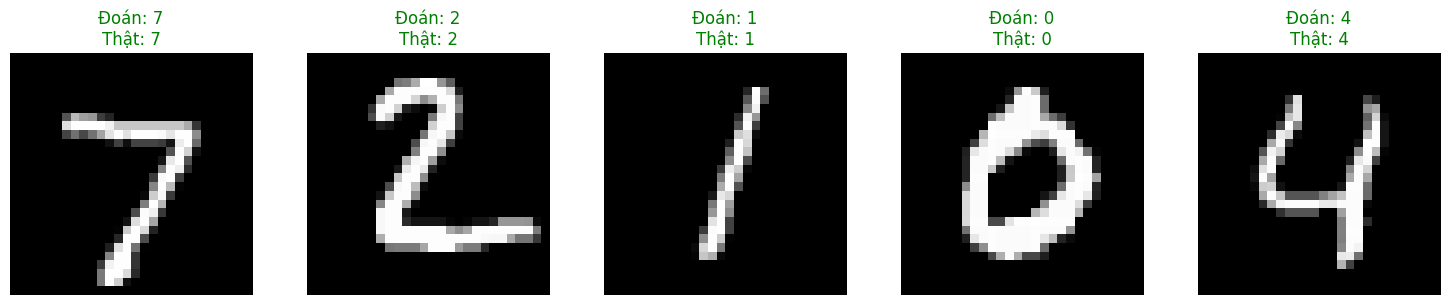

In [5]:
#trực quan: model dự đoán
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

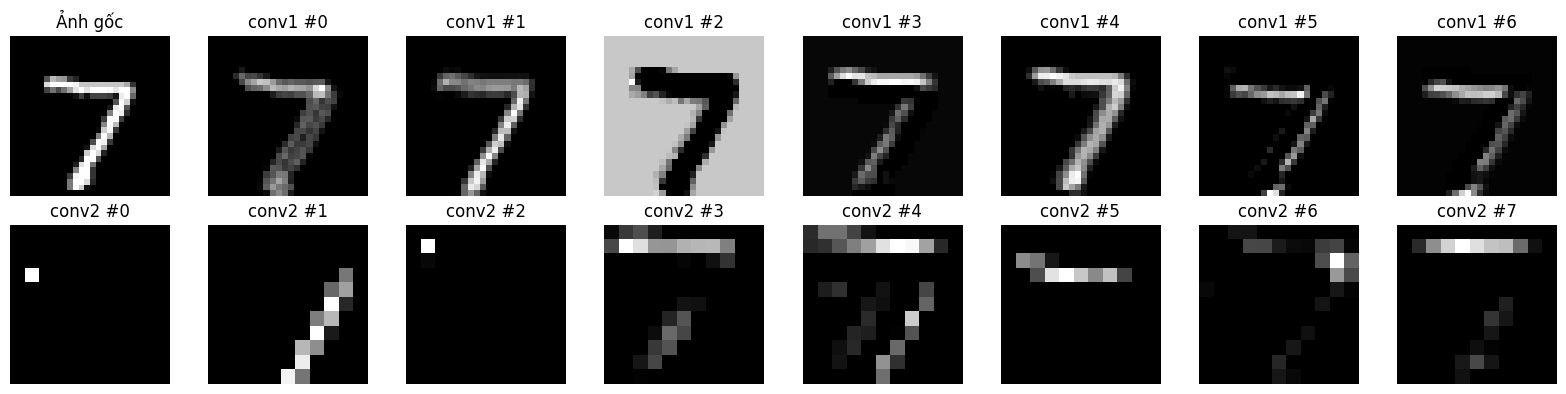

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [6]:
#trực quan: feature map
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

In [7]:
#Bài 1: từ 5 epoch --> 10 epoch
#Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
#Khoảng cách train_acc - test_acc mở rộng dần không? Đó là dấu hiệu gì?
num_epochs = 10

train_accs = []
test_accs = []

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # ===== TEST =====
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )
print("\n===== REPORT =====")

print(f"Epoch 5  - Train Acc: {train_accs[4]:.2f}%")
print(f"Epoch 5  - Test  Acc: {test_accs[4]:.2f}%")

print(f"\nEpoch 10 - Train Acc: {train_accs[9]:.2f}%")
print(f"Epoch 10 - Test  Acc: {test_accs[9]:.2f}%")

improvement = test_accs[9] - test_accs[4]

print(f"\nTest Accuracy Change: {improvement:.2f}%")

gap_epoch5 = train_accs[4] - test_accs[4]
gap_epoch10 = train_accs[9] - test_accs[9]

print(f"Gap Epoch 5  : {gap_epoch5:.2f}%")
print(f"Gap Epoch 10 : {gap_epoch10:.2f}%")

if gap_epoch10 > gap_epoch5:
    print("=> Gap tăng, mô hình có dấu hiệu overfitting.")
else:
    print("=> Chưa thấy dấu hiệu overfitting rõ ràng.")

Epoch [1/10] Train Acc: 98.99% | Test Acc: 98.93%
Epoch [2/10] Train Acc: 99.10% | Test Acc: 98.76%
Epoch [3/10] Train Acc: 99.23% | Test Acc: 98.87%
Epoch [4/10] Train Acc: 99.26% | Test Acc: 98.92%
Epoch [5/10] Train Acc: 99.36% | Test Acc: 98.99%
Epoch [6/10] Train Acc: 99.41% | Test Acc: 98.94%
Epoch [7/10] Train Acc: 99.44% | Test Acc: 98.94%
Epoch [8/10] Train Acc: 99.54% | Test Acc: 98.93%
Epoch [9/10] Train Acc: 99.58% | Test Acc: 99.03%
Epoch [10/10] Train Acc: 99.63% | Test Acc: 98.87%

===== REPORT =====
Epoch 5  - Train Acc: 99.36%
Epoch 5  - Test  Acc: 98.99%

Epoch 10 - Train Acc: 99.63%
Epoch 10 - Test  Acc: 98.87%

Test Accuracy Change: -0.12%
Gap Epoch 5  : 0.37%
Gap Epoch 10 : 0.76%
=> Gap tăng, mô hình có dấu hiệu overfitting.


In [9]:
#Câu 2 :Thêm conv3 để mạng sâu hơn.
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1: 28x28 -> 26x26
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=0
        )

        # Conv2: 13x13 -> 11x11
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=0
        )

        # Conv3: giữ nguyên kích thước 5x5
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Sau conv3 + pool:
        # (64, 5, 5) -> (64, 2, 2)
        self.fc1 = nn.Linear(
            64 * 2 * 2,
            10
        )

    def forward(self, x):

        # (1,28,28) -> (16,13,13)
        x = self.pool(F.relu(self.conv1(x)))

        # (16,13,13) -> (32,5,5)
        x = self.pool(F.relu(self.conv2(x)))

        # (32,5,5) -> (64,2,2)
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.fc1(x)

        return x


#tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNIST_CNN_3Conv().to(device)

print(model)

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Tổng tham số: {n_params:,}")


#Khai báo loss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)


MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866



Training with lr = 0.001
Epoch [1/5] Loss: 0.4466
Epoch [2/5] Loss: 0.1574
Epoch [3/5] Loss: 0.1114
Epoch [4/5] Loss: 0.0927
Epoch [5/5] Loss: 0.0801

Training with lr = 0.01
Epoch [1/5] Loss: 0.1823
Epoch [2/5] Loss: 0.0654
Epoch [3/5] Loss: 0.0497
Epoch [4/5] Loss: 0.0408
Epoch [5/5] Loss: 0.0360

Training with lr = 0.1
Epoch [1/5] Loss: 0.1967
Epoch [2/5] Loss: 0.1144
Epoch [3/5] Loss: 0.1090
Epoch [4/5] Loss: 0.1057
Epoch [5/5] Loss: 0.1173


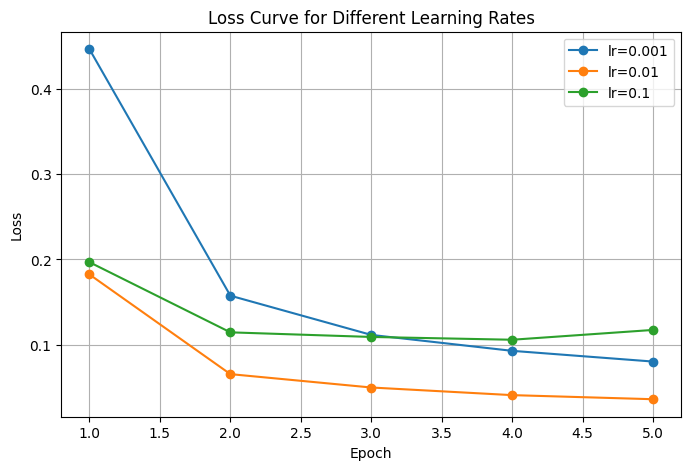

In [8]:
#Câu 3:Câu 3: Thay đổi learning rate
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1]

all_losses = {}

for lr in learning_rates:

    print(f"\nTraining with lr = {lr}")

    model = MNIST_CNN().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_losses = []

    for epoch in range(5):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        epoch_losses.append(avg_loss)

        print(
            f"Epoch [{epoch+1}/5] "
            f"Loss: {avg_loss:.4f}"
        )

    all_losses[lr] = epoch_losses
#3 đường loss đồ thị
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for lr, losses in all_losses.items():
    plt.plot(
        range(1, 6),
        losses,
        marker='o',
        label=f'lr={lr}'
    )

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve for Different Learning Rates')
plt.legend()
plt.grid(True)

plt.show()

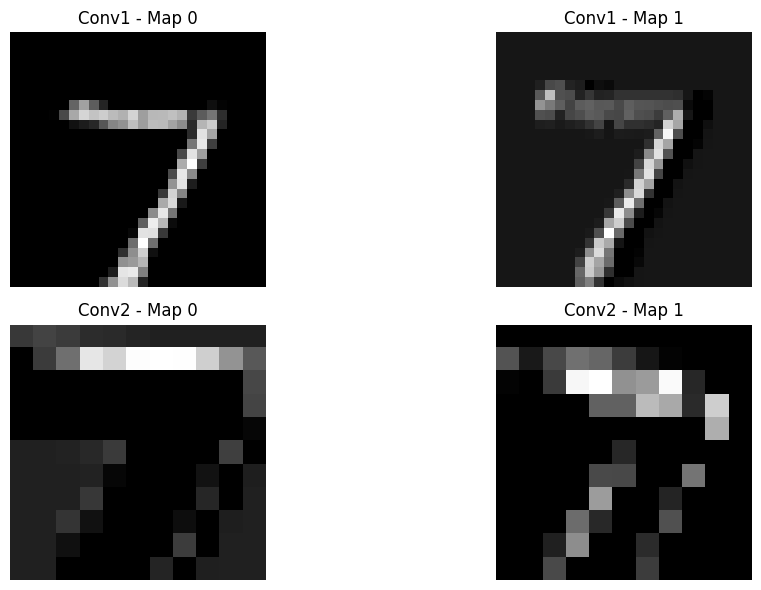

In [10]:
#Câu 4: Vẽ thêm feature maps từ conv2
import matplotlib.pyplot as plt
import torch

# Lấy 1 ảnh từ test set
img, label = test_dataset[0]

# Thêm chiều batch
img = img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    # Conv1
    h1 = torch.relu(model.conv1(img))
    h1_pool = model.pool(h1)

    # Conv2
    h2 = torch.relu(model.conv2(h1_pool))

# Chuyển về CPU để vẽ
h1 = h1.cpu()
h2 = h2.cpu()

plt.figure(figsize=(12,6))

# 2 feature maps từ conv1
for i in range(2):
    plt.subplot(2, 2, i + 1)
    plt.imshow(h1[0, i].numpy(), cmap='gray')
    plt.title(f'Conv1 - Map {i}')
    plt.axis('off')

# 2 feature maps từ conv2
for i in range(2):
    plt.subplot(2, 2, i + 3)
    plt.imshow(h2[0, i].numpy(), cmap='gray')
    plt.title(f'Conv2 - Map {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
#Câu 5: Thêm Dropout và Data Augmentation

#tạo 2 transform riêng
from torchvision import transforms
import torchvision

train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#tạo dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

#dataloader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

#thêm dropout vào CNN
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p=0.25)

        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)

        return x

#train 10 epoch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MNIST_CNN_Dropout().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

num_epochs = 10
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train Acc: {train_acc:.2f}%"
    )


#đánh giá test acc
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Epoch 1/10 - Train Acc: 85.08%
Epoch 2/10 - Train Acc: 95.17%
Epoch 3/10 - Train Acc: 96.29%
Epoch 4/10 - Train Acc: 96.80%
Epoch 5/10 - Train Acc: 97.15%
Epoch 6/10 - Train Acc: 97.36%
Epoch 7/10 - Train Acc: 97.46%
Epoch 8/10 - Train Acc: 97.67%
Epoch 9/10 - Train Acc: 97.83%
Epoch 10/10 - Train Acc: 98.03%
Test Accuracy: 99.29%
